# J04 — Écoulement de l'eau en sol saturé

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 4 : perméamètres, sol stratifié, écartement de drains (Hooghoudt), Laplace 2D par différences finies*

> Version **instructeur** : code complet et résultats.

## Mise en place

Unités : cm et jours pour les sols (convention du cours et de HYDRUS-1D), m et jours pour le drainage et Laplace 2D.
$z$ positif vers le haut, $q > 0$ vers le haut, $H = h + z$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, sparse
from scipy.sparse.linalg import spsolve

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
RHO_W, G = 998.2, 9.81                     # kg/m³, m/s²
T_TAB  = np.array([5, 10, 15, 18, 20, 25, 30])
MU_TAB = np.array([1.519, 1.307, 1.139, 1.053, 1.002, 0.890, 0.798]) * 1e-3   # Pa s
viscosite = lambda T: np.interp(T, T_TAB, MU_TAB)

## Exercice 1 — Perméamètres à charge constante et à charge variable  *(≈ 15 min)*

1. `data/J04_permeametre_charge_constante.csv` : quatre échantillons (S1–S4) mesurés trois fois chacun à 18 °C
   ($L$, $A$, $\Delta H$, volume $V$ recueilli en $t$). Calculer $K_s = V L/(A\,\Delta H\,t)$ pour chaque essai (cm/s → cm/j et m/s),
   puis la moyenne et l'écart type par échantillon ; ramener à 20 °C : $K_s(20) = K_s(T)\,\mu(T)/\mu(20)$.
2. `data/J04_permeametre_charge_variable.csv` : lectures $h(t)$ pour deux échantillons (colonnes `a_cm2`, `A_cm2`, `L_cm`).
   Ajuster $\ln(h_0/h) = (A K_s/aL)\,t$ par régression linéaire (`np.polyfit(..., cov=True)`) ; en déduire $K_s$ et son erreur type ;
   tracer les points et la droite.
3. Comparer les $K_s$ mesurées à l'estimation de Kozeny–Carman, $K_s = (\rho_w g/\mu)\, n^3 d^2/[180(1-n)^2]$ avec $d = d_{10}$,
   pour S1–S4 (colonnes `d10_mm`, `n`). Commenter les écarts.

,echantillon,texture,repetition,dH_cm,V_cm3,t_s,Ks_cms,Ks_20_cmj
0,S1,sable moyen,1,20.0,50.3,60,0.02135,1938.34119
1,S1,sable moyen,2,10.0,26.5,60,0.02249,2042.38734
2,S1,sable moyen,3,20.0,52.7,60,0.02237,2030.82666
3,S2,sable fin,1,15.0,23.3,120,0.00659,598.58648
4,S2,sable fin,2,20.0,33.3,120,0.00707,641.61791
5,S2,sable fin,3,10.0,14.4,120,0.00611,554.91279
6,S3,loam sableux,1,15.0,19.0,600,0.00108,97.62355
7,S3,loam sableux,2,10.0,12.8,600,0.00109,98.65116
8,S3,loam sableux,3,15.0,18.8,600,0.00106,96.59593
9,S4,loam,1,20.0,15.4,1800,0.00022,19.78161


Charge constante, Ks à 20 °C :


,,mean,std,CV_%,Ks_20_ms
echantillon,texture,,,,
S1,sable moyen,2003.8517,57.0275,2.8459,0.0002
S2,sable fin,598.3724,43.3530,7.2451,0.0001
S3,loam sableux,97.6235,1.0276,1.0526,0.0000
S4,loam,20.1812,0.3461,1.7149,0.0000


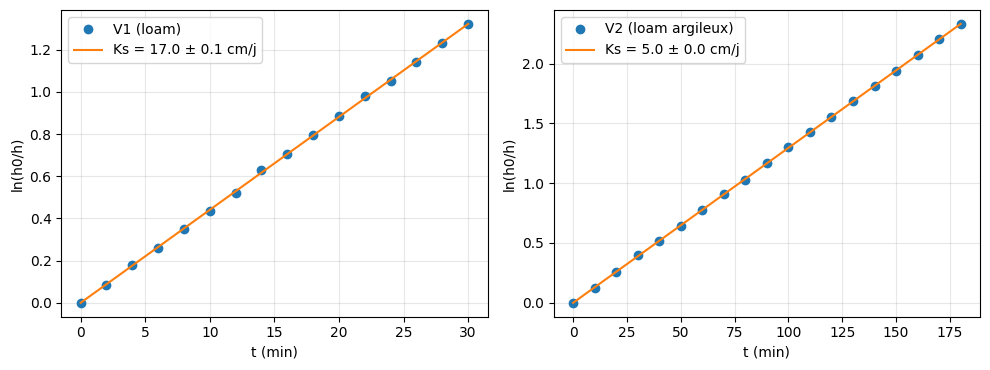

Charge variable, Ks à 20 °C :


,Ks_20_cmj,erreur_type_cmj,r2
V1,16.995,0.056,1.0
V2,4.991,0.009,1.0


,texture,d10_mm,n,Ks_KC_cmj,Ks_mesuree_cmj,rapport mesure/KC
echantillon,,,,,,
S1,sable moyen,0.15,0.38,1506.64,2003.85,1.33
S2,sable fin,0.08,0.40,533.72,598.37,1.12
S3,loam sableux,0.04,0.42,165.30,97.62,0.59
S4,loam,0.02,0.45,56.52,20.18,0.36


In [2]:
cc = pd.read_csv("data/J04_permeametre_charge_constante.csv")
cv = pd.read_csv("data/J04_permeametre_charge_variable.csv")

# 1. charge constante : Ks = V L / (A dH t), correction de température
cc["Ks_cms"] = cc["V_cm3"] * cc["L_cm"] / (cc["A_cm2"] * cc["dH_cm"] * cc["t_s"])
cc["Ks_20_cmj"] = cc["Ks_cms"] * viscosite(cc["T_C"]) / viscosite(20) * 86400
cc["Ks_20_ms"] = cc["Ks_20_cmj"] / 8.64e6
display(cc[["echantillon", "texture", "repetition", "dH_cm", "V_cm3", "t_s", "Ks_cms", "Ks_20_cmj"]].round(5))
res_cc = cc.groupby(["echantillon", "texture"])["Ks_20_cmj"].agg(["mean", "std"])
res_cc["CV_%"] = 100 * res_cc["std"] / res_cc["mean"]
res_cc["Ks_20_ms"] = res_cc["mean"] / 8.64e6
print("Charge constante, Ks à 20 °C :"); display(res_cc.round(4))

# 2. charge variable : ln(h0/h) = (A Ks / (a L)) t
def ks_charge_variable(g):
    t, h = g["t_s"].to_numpy(), g["h_cm"].to_numpy()
    a, A, L, T = (g[c].iloc[0] for c in ["a_cm2", "A_cm2", "L_cm", "T_C"])
    y = np.log(h[0] / h)
    (p, b), cov = np.polyfit(t, y, 1, cov=True)
    Ks = p * a * L / A                              # cm/s à T
    err = np.sqrt(cov[0, 0]) * a * L / A
    f = viscosite(T) / viscosite(20) * 86400        # -> cm/j à 20 °C
    return dict(Ks_20_cmj=Ks * f, erreur_type_cmj=err * f, r2=1 - np.sum((y - np.polyval([p, b], t))**2) / np.sum((y - y.mean())**2))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
res_cv = {}
for k, (sid, g) in enumerate(cv.groupby("echantillon")):
    r = ks_charge_variable(g); res_cv[sid] = r
    t, h = g["t_s"].to_numpy(), g["h_cm"].to_numpy()
    ax[k].plot(t / 60, np.log(h[0] / h), "o", label=f"{sid} ({g['texture'].iloc[0]})")
    p = np.polyfit(t, np.log(h[0] / h), 1)
    ax[k].plot(t / 60, np.polyval(p, t), "-", label=f"Ks = {r['Ks_20_cmj']:.1f} ± {r['erreur_type_cmj']:.1f} cm/j")
    ax[k].set_xlabel("t (min)"); ax[k].set_ylabel("ln(h0/h)"); ax[k].legend()
plt.tight_layout(); plt.show()
print("Charge variable, Ks à 20 °C :"); display(pd.DataFrame(res_cv).T.round(3))

# 3. Kozeny-Carman
def kozeny_carman(d_m, n, T=20):
    """Ks (m/s) de Kozeny-Carman avec d = diamètre efficace (m) et porosité n."""
    return RHO_W * G / viscosite(T) * n**3 / (180 * (1 - n)**2) * d_m**2

kc = cc.groupby("echantillon").first()[["texture", "d10_mm", "n"]]
kc["Ks_KC_cmj"] = kozeny_carman(kc["d10_mm"] * 1e-3, kc["n"]) * 8.64e6
kc["Ks_mesuree_cmj"] = res_cc["mean"].to_numpy()
kc["rapport mesure/KC"] = kc["Ks_mesuree_cmj"] / kc["Ks_KC_cmj"]
display(kc.round(2))

**Commentaire (instructeur).** Les répétitions à charge constante dispersent de ~5 % (CV) : c'est la précision de la méthode sur un même échantillon, très
inférieure à la variabilité spatiale de $K_s$ (CV > 100 %). La correction de température (18 → 20 °C) vaut +5 % : négligeable
devant cette variabilité, mais indispensable pour comparer des laboratoires. Kozeny–Carman est du bon ordre de grandeur pour les
sables (rapport 0,5–2) mais s'écarte pour les loams : $d_{10}$ ne décrit plus la géométrie des pores fins et la structure
n'est pas prise en compte.

## Exercice 2 — Sol à trois couches : flux et profils de charge  *(≈ 15 min)*

Sable ($K_1 = 50$ cm/j, 30 cm) sur argile ($K_2 = 0{,}5$ cm/j, 10 cm) sur sable ($K_3 = 20$ cm/j, 60 cm) ; lame d'eau de 5 cm en
surface ($H_{haut} = 5$ cm) ; nappe à la base ($z = -100$ cm, $h = 0$, $H_{bas} = -100$ cm).

1. Écrire `profil_serie(K, L, H_haut, H_bas)` qui retourne $K_\perp = \sum L_i / \sum (L_i/K_i)$, le flux $q = -K_\perp \Delta H/\sum L_i$
   et les tableaux $z$, $H$, $h$ aux interfaces (en supposant tout saturé).
2. Tracer $H(z)$ et $h(z)$ ; où la pression devient-elle négative ? Quelle fraction de la perte de charge a lieu dans l'argile ?
3. Nappe perchée : recalculer le flux en imposant $h = 0$ à la base de l'argile ($H = -40$ cm) sur les deux couches supérieures ;
   comparer au cas « tout saturé ».
4. Remplacer l'argile par un loam ($K_2 = 25$ cm/j) : le profil reste-t-il saturé ? Flux ?

K_eq = 4.237 cm/j ; q = -4.449 cm/j (vers le bas)


,z (cm),H (cm),h (cm)
surface,0.0,5.00,5.00
sable/argile,-30.0,2.33,32.33
argile/sable,-40.0,-86.65,-46.65
base,-100.0,-100.00,0.00


Perte de charge par couche (cm) : [ 2.67 88.98 13.35] -> 85 % dans l'argile
Pression négative sous l'argile : h = -46.7 cm -> hypothèse saturée violée dans le sable inférieur
Nappe perchée : q = -2.18 cm/j (contre -4.45 tout saturé) ; h à la base du sable supérieur = 33.7 cm
Avec un loam : K_eq = 25.00 cm/j, q = -26.25 cm/j, h min = 0.0 cm -> profil saturé partout


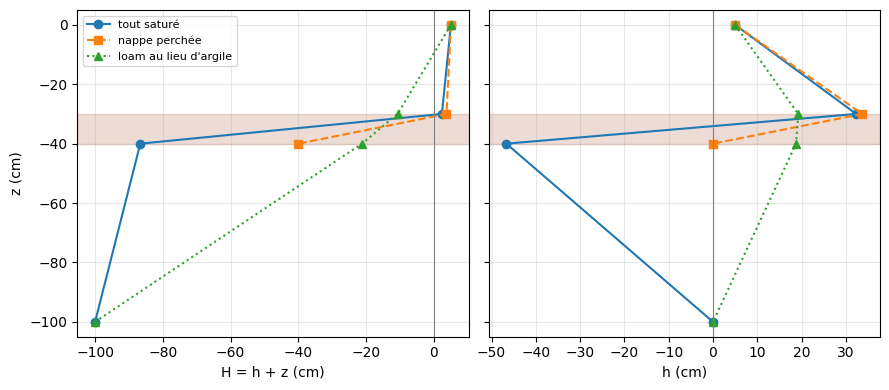

In [3]:
def profil_serie(K, L, H_haut, H_bas):
    """Écoulement vertical permanent à travers des couches en série (tout saturé).
    Retourne K_eq (cm/j), q (cm/j, > 0 vers le haut), z, H, h aux interfaces (cm)."""
    K, L = np.asarray(K, float), np.asarray(L, float)
    K_eq = L.sum() / np.sum(L / K)
    q = -K_eq * (H_haut - H_bas) / L.sum()          # < 0 : vers le bas
    z = np.concatenate([[0.0], -np.cumsum(L)])
    H = H_haut - np.concatenate([[0.0], np.cumsum(np.abs(q) * L / K)])
    h = H - z
    return K_eq, q, z, H, h

K, L = [50, 0.5, 20], [30, 10, 60]
K_eq, q, z, H, h = profil_serie(K, L, 5.0, -100.0)
tab = pd.DataFrame({"z (cm)": z, "H (cm)": H, "h (cm)": h}, index=["surface", "sable/argile", "argile/sable", "base"])
print(f"K_eq = {K_eq:.3f} cm/j ; q = {q:.3f} cm/j (vers le bas)"); display(tab.round(2))
dH = np.abs(q) * np.array(L) / np.array(K)
print("Perte de charge par couche (cm) :", np.round(dH, 2), f"-> {100*dH[1]/dH.sum():.0f} % dans l'argile")
print("Pression négative sous l'argile : h =", round(h[2], 1), "cm -> hypothèse saturée violée dans le sable inférieur")

# 3. nappe perchée : h = 0 à la base de l'argile (H = -40 cm), sable + argile en série
K_eq2, q2, z2, H2, h2 = profil_serie(K[:2], L[:2], 5.0, -40.0)
print(f"Nappe perchée : q = {q2:.2f} cm/j (contre {q:.2f} tout saturé) ; h à la base du sable supérieur = {h2[1]:.1f} cm")

# 4. argile remplacée par un loam
K_eq3, q3, z3, H3, h3 = profil_serie([50, 25, 20], L, 5.0, -100.0)
print(f"Avec un loam : K_eq = {K_eq3:.2f} cm/j, q = {q3:.2f} cm/j, h min = {h3.min():.1f} cm -> "
      + ("profil saturé partout" if h3.min() >= 0 else "pression négative"))

fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
ax[0].plot(H, z, "o-", label="tout saturé"); ax[0].plot(H2, z2, "s--", label="nappe perchée"); ax[0].plot(H3, z3, "^:", label="loam au lieu d'argile")
ax[1].plot(h, z, "o-"); ax[1].plot(h2, z2, "s--"); ax[1].plot(h3, z3, "^:")
for a in ax:
    a.axhspan(-40, -30, color="sienna", alpha=0.2); a.axvline(0, color="gray", lw=0.8)
ax[0].set_xlabel("H = h + z (cm)"); ax[0].set_ylabel("z (cm)"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("h (cm)"); plt.tight_layout(); plt.show()

**Commentaire (instructeur).** La couche d'argile absorbe 85 % de la perte de charge et impose le flux (4,45 cm/j) ; sous elle, $h = -47$ cm : le sable inférieur
ne peut pas rester saturé. En réalité une nappe perchée se forme sur l'argile et le flux tombe à 2,2 cm/j (limité par l'argile
avec $h \approx 0$ à sa base). Avec un loam à la place de l'argile, la perte de charge se répartit, $h$ reste positif partout
et le flux atteint ~ 26 cm/j : la couche la moins perméable contrôle tout.

## Exercice 3 — Écartement de drains : Hooghoudt et profondeur équivalente  *(≈ 15 min)*

Équation de Hooghoudt : $L^2 = (8 K_b d_e h + 4 K_a h^2)/q$ (m, j), avec la profondeur équivalente de van der Molen & Wesseling (1991) :

$d_e = \dfrac{\pi L/8}{\ln[L/(\pi r_0)] + F(x)}$, $x = 2\pi D/L$, $F(x) = \sum_{j=1,3,5,\dots} \dfrac{4 e^{-2jx}}{j(1-e^{-2jx})}$ pour $x > 0{,}5$
et $F(x) \approx \pi^2/(4x) + \ln[x/(2\pi)]$ pour $x < 0{,}5$.

1. Programmer `de_vdmw(L, D, r0)` ; vérifier : $L = 20$ m, $D = 1$ m, $r_0 = 0{,}1$ m → $d_e \approx 0{,}87$ m ; $D = 1000$ m → $\approx 1{,}89$ m ;
   $D = 0{,}5$ m → $\approx 0{,}49$ m ($\approx D$).
2. Programmer `ecartement_drains(q, K, h, D, r0, Ka=None)` (itération de point fixe : $L \to d_e \to L$) ; retrouver
   $L = 28{,}3$ m pour $q = 7$ mm/j, $K = 0{,}8$ m/j, $h = 0{,}5$ m, $D = 2$ m, $r_0 = 0{,}1$ m.
3. Table de $L$ pour $K \in \{0{,}2 ; 0{,}5 ; 1 ; 2\}$ m/j et $D \in \{0{,}5 ; 1 ; 2 ; 5 ; 1000\}$ m ; graphique $L(K)$ pour chaque $D$.
4. Sensibilité (cas de référence) : variation relative de $L$ pour $K \times 0{,}5$ et $\times 2$, et pour $h = 0{,}4$ et $0{,}6$ m.

Vérifications d_e : 0.872 1.891 0.486
Exemple du cours : L = 28.28 m, d_e = 1.500 m
Écartement L (m) pour q = 7 mm/j, h = 0,5 m, r0 = 0,1 m :


,K = 0.2 m/j,K = 0.5 m/j,K = 1.0 m/j,K = 2.0 m/j
D = 0.5 m,9.1,14.4,20.5,29.1
D = 1 m,10.9,17.8,25.6,36.7
D = 2 m,12.6,21.7,32.0,46.8
D = 5 m,13.8,26.1,41.0,62.8
D -> inf,13.9,27.6,47.7,83.8


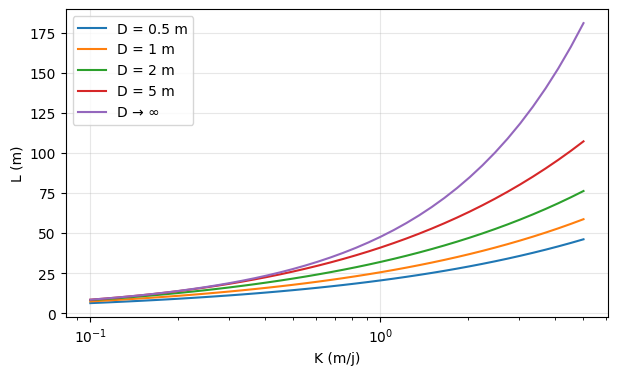

,L (m),variation (%)
"K x 0,5",19.1,-32.6
K x 2,41.5,46.6
"h = 0,4 m",24.5,-13.3
"h = 0,6 m",31.8,12.4
q = 5 mm/j,34.1,20.6
q = 10 mm/j,23.1,-18.3


In [4]:
def de_vdmw(L, D, r0):
    """Profondeur équivalente de Hooghoudt (van der Molen & Wesseling 1991), unités cohérentes (m)."""
    x = 2 * np.pi * D / L
    if x < 0.5:
        F = np.pi**2 / (4 * x) + np.log(x / (2 * np.pi))
    else:
        j = np.arange(1, 400, 2); e = np.exp(-2 * j * x)
        F = np.sum(4 * e / (j * (1 - e)))
    return np.pi * L / (8 * (np.log(L / (np.pi * r0)) + F))

def ecartement_drains(q, K, h, D, r0=0.1, Ka=None, tol=1e-6):
    """Écartement L (m) : Hooghoudt L² = (8 Kb de h + 4 Ka h²)/q, d_e itéré (point fixe)."""
    Ka = K if Ka is None else Ka
    L = 30.0
    for _ in range(200):
        de = de_vdmw(L, D, r0)
        L_new = np.sqrt((8 * K * de * h + 4 * Ka * h**2) / q)
        if abs(L_new - L) < tol:
            break
        L = L_new
    return L_new

print("Vérifications d_e :", round(de_vdmw(20, 1, 0.1), 3), round(de_vdmw(20, 1000, 0.1), 3), round(de_vdmw(20, 0.5, 0.1), 3))
L_ref = ecartement_drains(0.007, 0.8, 0.5, 2.0, 0.1)
print(f"Exemple du cours : L = {L_ref:.2f} m, d_e = {de_vdmw(L_ref, 2.0, 0.1):.3f} m")

# 3. table L(K, D)
Ks_ = [0.2, 0.5, 1.0, 2.0]; Ds = [0.5, 1, 2, 5, 1000]
tab = pd.DataFrame([[ecartement_drains(0.007, K, 0.5, D) for K in Ks_] for D in Ds],
                   index=[f"D = {D} m" if D < 1000 else "D -> inf" for D in Ds], columns=[f"K = {K} m/j" for K in Ks_])
print("Écartement L (m) pour q = 7 mm/j, h = 0,5 m, r0 = 0,1 m :"); display(tab.round(1))
Kv = np.logspace(-1, 0.7, 40)
fig, ax = plt.subplots()
for D in Ds:
    ax.plot(Kv, [ecartement_drains(0.007, K, 0.5, D) for K in Kv], label=f"D = {D} m" if D < 1000 else "D → ∞")
ax.set_xscale("log"); ax.set_xlabel("K (m/j)"); ax.set_ylabel("L (m)"); ax.legend(); plt.show()

# 4. sensibilité
sens = {"K x 0,5": ecartement_drains(0.007, 0.4, 0.5, 2.0), "K x 2": ecartement_drains(0.007, 1.6, 0.5, 2.0),
        "h = 0,4 m": ecartement_drains(0.007, 0.8, 0.4, 2.0), "h = 0,6 m": ecartement_drains(0.007, 0.8, 0.6, 2.0),
        "q = 5 mm/j": ecartement_drains(0.005, 0.8, 0.5, 2.0), "q = 10 mm/j": ecartement_drains(0.010, 0.8, 0.5, 2.0)}
sens = pd.DataFrame({"L (m)": sens, "variation (%)": {k: 100 * (v / L_ref - 1) for k, v in sens.items()}})
display(sens.round(1))

**Commentaire (instructeur).** $L$ varie comme $\sqrt{K}$ et $\sqrt{1/q}$ (±40 % pour un facteur 2), et à peu près linéairement avec $h$ (±20 % pour ±20 %).
La conductivité, connue au mieux à un facteur 2 près, est donc le paramètre à mesurer en priorité (trou à la tarière, plusieurs
points). La couche imperméable profonde ($D \to \infty$) augmente $L$ jusqu'à 60 % par rapport à $D = 0{,}5$ m pour $K = 2$ m/j : la
prospection de la profondeur du substratum fait partie du dimensionnement.

## Exercice 4 — Laplace 2D par différences finies : écoulement sous une palplanche  *(≈ 15 min)*

Domaine $30 \times 15$ m (grille $61 \times 31$, $\Delta = 0{,}5$ m), $K = 1$ m/j, palplanche en $x = 15$ m fichée à 6 m (elle coupe la
connexion entre les colonnes $i_p - 1$ et $i_p$ jusqu'à $z = -6$ m). Surface : $H = 4$ m à l'amont ($x < 15$), $H = 0$ à l'aval ;
parois latérales et fond imperméables (Neumann : nœud miroir).

1. Construire les tableaux d'indices des quatre voisins de chaque nœud (avec les miroirs) et implémenter un solveur
   Gauss–Seidel **vectorisé** par balayage en damier rouge–noir, avec sur-relaxation ($\omega = 1{,}8$) et critère
   $\max|\Delta H| < 10^{-6}$ m. Combien d'itérations ?
2. Comparer à la solution directe (matrice creuse + `spsolve`) : écart maximal.
3. Tracer les équipotentielles et le champ de flux ($q_x = -K\,\partial H/\partial x$, $q_z = -K\,\partial H/\partial z$).
4. Calculer le débit de fuite $Q$ (m³/j par m) par la surface aval, le débit entrant à l'amont (bilan), le facteur de forme
   $Q/(K\Delta H) = N_f/N_d$ et le gradient hydraulique de sortie à l'aval, contre la palplanche (à comparer au gradient critique $\approx 1$).

SOR (ω = 1,8) : convergence en 508 itérations


Gauss-Seidel (ω = 1) : 3435 itérations
Écart max SOR vs solution directe : 7.36e-05 m


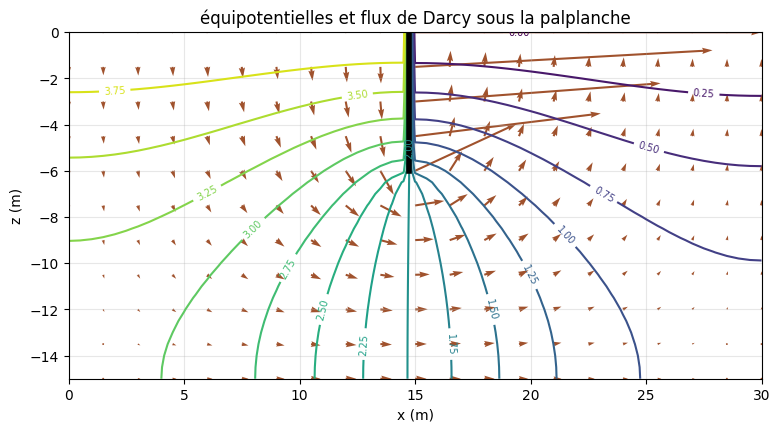

Débit de fuite Q = 2.030 m³/j par m ; entrée = 2.032 ; écart de bilan = 0.06 %
Facteur de forme Q/(K ΔH) = Nf/Nd = 0.508
Gradient de sortie contre la palplanche (aval) : i = 0.19 (critique ≈ 1 : sécurité 5.4)


In [5]:
nx, nz, dx = 61, 31, 0.5
Kh = 1.0; H_am, H_av = 4.0, 0.0
ip, zp = 30, 12                       # palplanche entre les colonnes ip-1 et ip, lignes 0..zp (z = 0 à -6 m)

def voisins(nx, nz, ip, zp):
    """Indices des voisins gauche/droite/haut/bas avec miroirs (Neumann) et palplanche imperméable."""
    J, I = np.meshgrid(np.arange(nz), np.arange(nx), indexing="ij")
    Il = np.where(I > 0, I - 1, I + 1); Ir = np.where(I < nx - 1, I + 1, I - 1)
    Ju = np.where(J > 0, J - 1, J + 1); Jd = np.where(J < nz - 1, J + 1, J - 1)
    pile = J <= zp
    Ir = np.where(pile & (I == ip - 1), I - 1, Ir)      # miroir à droite de la colonne ip-1
    Il = np.where(pile & (I == ip), I + 1, Il)          # miroir à gauche de la colonne ip
    return (J, Il), (J, Ir), (Ju, I), (Jd, I)

def sor(H, vois, libre, omega=1.8, tol=1e-6, itmax=50000):
    """Gauss-Seidel vectorisé (damier rouge-noir) avec sur-relaxation ; H modifié en place."""
    J, I = np.indices(H.shape)
    damier = (I + J) % 2
    for it in range(1, itmax + 1):
        dmax = 0.0
        for couleur in (0, 1):
            m = libre & (damier == couleur)
            Hgs = 0.25 * (H[vois[0]] + H[vois[1]] + H[vois[2]] + H[vois[3]])
            dH = omega * (Hgs - H)
            dmax = max(dmax, np.abs(dH[m]).max())
            H[m] += dH[m]
        if dmax < tol:
            return it
    return it

# conditions aux limites et état initial
H = np.zeros((nz, nx))
H[0, :ip] = H_am; H[0, ip:] = H_av                     # Dirichlet en surface
libre = np.ones((nz, nx), bool); libre[0, :] = False
vois = voisins(nx, nz, ip, zp)
H[1:, :] = 2.0                                          # initialisation
n_it = sor(H, vois, libre, omega=1.8)
print(f"SOR (ω = 1,8) : convergence en {n_it} itérations")
H_gs = H.copy(); n_gs = sor(np.where(libre, 2.0, H), vois, libre, omega=1.0)   # comparaison sans sur-relaxation
print(f"Gauss-Seidel (ω = 1) : {n_gs} itérations")

# 2. solution directe (matrice creuse)
N = nx * nz; idx = lambda j, i: j * nx + i
rows, cols, vals, b = [], [], [], np.zeros(N)
for j in range(nz):
    for i in range(nx):
        n = idx(j, i)
        if not libre[j, i]:
            rows.append(n); cols.append(n); vals.append(1.0); b[n] = H[j, i]; continue
        rows.append(n); cols.append(n); vals.append(-4.0)
        for (JJ, II) in vois:
            rows.append(n); cols.append(idx(JJ[j, i], II[j, i])); vals.append(1.0)
A = sparse.csr_matrix((vals, (rows, cols)), shape=(N, N))
H_dir = spsolve(A, b).reshape(nz, nx)
print(f"Écart max SOR vs solution directe : {np.abs(H - H_dir).max():.2e} m")

# 3. équipotentielles et flux
X = np.arange(nx) * dx; Z = -np.arange(nz) * dx
qx = np.zeros_like(H); qz = np.zeros_like(H)
qx[:, 1:-1] = -Kh * (H[:, 2:] - H[:, :-2]) / (2 * dx)
qz[1:-1, :] = -Kh * (H[:-2, :] - H[2:, :]) / (2 * dx)        # z vers le haut : la ligne j-1 est au-dessus
fig, ax = plt.subplots(figsize=(9, 4.5))
cs = ax.contour(X, Z, H, levels=np.linspace(0, 4, 17), cmap="viridis"); ax.clabel(cs, fmt="%.2f", fontsize=7)
sk = 3
ax.quiver(X[::sk], Z[::sk], qx[::sk, ::sk], qz[::sk, ::sk], color="sienna", scale=8, width=0.003)
ax.plot([X[ip] - dx / 2] * 2, [0, Z[zp]], "k-", lw=4)
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)"); ax.set_title("équipotentielles et flux de Darcy sous la palplanche")
plt.show()

# 4. débits, bilan, facteur de forme, gradient de sortie
q_surf = -Kh * (H[0, :] - H[1, :]) / dx                 # flux vertical à la surface (> 0 vers le haut)
Q_out = np.sum(q_surf[ip:]) * dx                        # sortie côté aval
Q_in = -np.sum(q_surf[:ip]) * dx                        # entrée côté amont
print(f"Débit de fuite Q = {Q_out:.3f} m³/j par m ; entrée = {Q_in:.3f} ; écart de bilan = {100*abs(Q_in-Q_out)/Q_out:.2f} %")
print(f"Facteur de forme Q/(K ΔH) = Nf/Nd = {Q_out / (Kh * (H_am - H_av)):.3f}")
i_sortie = (H[1, ip] - H[0, ip]) / dx
print(f"Gradient de sortie contre la palplanche (aval) : i = {i_sortie:.2f} (critique ≈ 1 : {'renard possible !' if i_sortie > 1 else 'sécurité ' + f'{1/i_sortie:.1f}'})")

**Commentaire (instructeur).** Le SOR converge en quelques centaines d'itérations contre plusieurs milliers pour Gauss–Seidel, et coïncide avec la solution
directe à $10^{-5}$ m près. Le bilan (entrée = sortie à mieux que 1 %) valide la discrétisation. Le facteur de forme
$N_f/N_d \approx 0{,}5$ est celui que l'on obtient en traçant le réseau à la main (≈ 5 tubes pour 10 chutes). Le gradient de
sortie contre la palplanche (~0,2 sur cette grille de 0,5 m) reste loin du gradient critique, mais il est sous-estimé par la
maille grossière : le raffinement près du pied de la palplanche (singularité) l'augmente nettement et doit être fait dans un
projet réel.

## Exercice 5 — Bonus — milieu anisotrope  *(≈ facultatif)*

Refaire l'exercice 4 avec $K_h = 4$ m/j et $K_v = 1$ m/j : le schéma devient
$H_{i,j} = [K_h(H_{i+1,j} + H_{i-1,j}) + K_v(H_{i,j+1} + H_{i,j-1})]/[2(K_h + K_v)]$ ($\Delta x = \Delta z$).
Comparer le débit de fuite (avec $q_x = -K_h\,\partial H/\partial x$, $q_z = -K_v\,\partial H/\partial z$) et l'allure des
équipotentielles au cas isotrope. Vérifier avec la transformation $x' = x\sqrt{K_v/K_h}$ : $Q_{aniso} \approx \sqrt{K_h K_v}\,\Delta H\,(N_f/N_d)'$.

Anisotrope (Kh = 4, Kv = 1) : 1077 itérations ; Q = 3.061 m³/j/m contre 2.030 isotrope (K = 1)
Q / (sqrt(Kh Kv) ΔH) = 0.383  (facteur de forme du domaine transformé, plus large : x' = x/2)


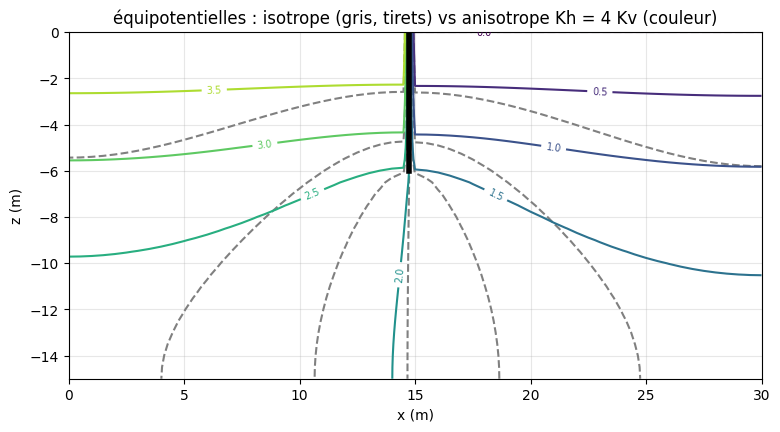

In [6]:
Kh2, Kv2 = 4.0, 1.0

def sor_aniso(H, vois, libre, Kh, Kv, omega=1.8, tol=1e-6, itmax=50000):
    J, I = np.indices(H.shape); damier = (I + J) % 2
    for it in range(1, itmax + 1):
        dmax = 0.0
        for couleur in (0, 1):
            m = libre & (damier == couleur)
            Hgs = (Kh * (H[vois[0]] + H[vois[1]]) + Kv * (H[vois[2]] + H[vois[3]])) / (2 * (Kh + Kv))
            dH = omega * (Hgs - H); dmax = max(dmax, np.abs(dH[m]).max()); H[m] += dH[m]
        if dmax < tol:
            return it
    return it

H2 = np.where(libre, 2.0, H)
n2 = sor_aniso(H2, vois, libre, Kh2, Kv2)
q_surf2 = -Kv2 * (H2[0, :] - H2[1, :]) / dx
Q2 = np.sum(q_surf2[ip:]) * dx
print(f"Anisotrope (Kh = 4, Kv = 1) : {n2} itérations ; Q = {Q2:.3f} m³/j/m contre {Q_out:.3f} isotrope (K = 1)")
print(f"Q / (sqrt(Kh Kv) ΔH) = {Q2 / (np.sqrt(Kh2 * Kv2) * 4):.3f}  (facteur de forme du domaine transformé, plus large : x' = x/2)")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.contour(X, Z, H, levels=np.linspace(0, 4, 9), colors="gray", linestyles="--")
cs = ax.contour(X, Z, H2, levels=np.linspace(0, 4, 9), cmap="viridis"); ax.clabel(cs, fmt="%.1f", fontsize=7)
ax.plot([X[ip] - dx / 2] * 2, [0, Z[zp]], "k-", lw=4); ax.set_aspect("equal")
ax.set_title("équipotentielles : isotrope (gris, tirets) vs anisotrope Kh = 4 Kv (couleur)"); ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
plt.show()

**Commentaire (instructeur).** Avec $K_h = 4K_v$, les équipotentielles s'aplatissent (l'eau contourne la palplanche plus loin horizontalement) et le débit augmente d'un facteur ~1,5 : moins que $\sqrt{K_h K_v} = 2$, parce que le facteur de forme du domaine transformé ($x' = x/2$, deux fois moins large pour la même profondeur) est plus petit (0,38 contre 0,51) : la palplanche barre une part relativement plus grande de la section d'écoulement.

## Pour aller plus loin

* Exercice 2 : traiter le cas non saturé sous l'argile avec $K(h)$ de van Genuchten–Mualem (Jour 5) et comparer au flux de la nappe perchée.
* Exercice 3 : ajouter la formule non permanente de Glover–Dumm pour la vidange après une pluie de 40 mm.
* Exercice 4 : raffiner la grille ($\Delta = 0{,}25$ m) et étudier la convergence du gradient de sortie ; ajouter un radier amont.